In [2]:
import matplotlib.pyplot as plt
import numpy as np
import PIL

from ai_edge_litert.interpreter import Interpreter
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import os

In [3]:
os.environ["CUDA_VIBLE_DEVICES"] = "-1"
model_mbnv2 = tf.keras.models.load_model("steel_defect_clf_mobile_netv2_fine_tuning_scaling_patch_augmented_less_aggressive.keras")

2025-11-09 16:48:46.687044: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
def get_file_size(file_path):
    """Prints the size of a file in MB."""
    size_bytes = os.path.getsize(file_path)
    size_mb = size_bytes / (1024 * 1024)
    return size_mb

In [5]:
print(f"Size of fine tuned model (MobileNetV2) = {get_file_size('steel_defect_clf_mobile_netv2_fine_tuning_scaling_patch_augmented_less_aggressive.keras')} MB")

Size of fine tuned model (MobileNetV2) = 23.332924842834473 MB


In [15]:
import pathlib

data_dir = pathlib.Path("/home/theorist/Desktop/Programming/ML/computing_tools/capstone-1/")
data_dir = data_dir / "train" / "images"
image_count = len(list(data_dir.glob('*/*.jpg')))

batch_size = 32
img_height = 224
img_width = 224

train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  color_mode='grayscale'  
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=1,
  color_mode='grayscale' 
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Class names: {class_names}")
print(f"Number of classes: {num_classes}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 1799 files belonging to 6 classes.
Using 1440 files for training.
Found 1799 files belonging to 6 classes.
Using 359 files for validation.
Class names: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Number of classes: 6


# 1. Baseline Keras model FP32

In [16]:
baseline_loss, baseline_acc = model_mbnv2.evaluate(val_ds)

359/359 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9916 - loss: 0.0230


In [17]:
print(f"Baseline Keras Accuracy: {baseline_acc}")

Baseline Keras Accuracy: 0.9916434288024902


# 2. Post training quantization: weights(FP32 -> INT8)

In [31]:
converter = tf.lite.TFLiteConverter.from_keras_model(model_mbnv2)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_dynamic_model = converter.convert()

tflite_dynamic_path = "mobilenetv2_dynamic_ptq.tflite"
with open(tflite_dynamic_path, 'wb') as f:
    f.write(tflite_dynamic_model)

INFO:tensorflow:Assets written to: /tmp/tmphcfvwjz8/assets


INFO:tensorflow:Assets written to: /tmp/tmphcfvwjz8/assets


Saved artifact at '/tmp/tmphcfvwjz8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 1), dtype=tf.float32, name='input_layer_28')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  138203807443152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138203807649808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138203807653504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138203807655616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138203807656496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138203807652976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138203807654208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138203807659488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138203807660368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138203807661424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138203807661

W0000 00:00:1762674674.772941  155397 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1762674674.772963  155397 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-11-09 13:21:14.773239: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmphcfvwjz8
2025-11-09 13:21:14.781706: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-11-09 13:21:14.781722: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmphcfvwjz8
I0000 00:00:1762674674.849286  155397 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2025-11-09 13:21:14.862441: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-11-09 13:21:15.459447: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmphcfvwjz8
2025-11-09 13:21:15.600279: I tensorflow/cc/saved_model/loader.cc:471] SavedModel 

In [32]:
TFLITE_DYNAMIC_MODEL_PATH = "mobilenetv2_dynamic_ptq.tflite"
interpreter = Interpreter(model_path=TFLITE_DYNAMIC_MODEL_PATH)
interpreter.allocate_tensors()

In [33]:
def evaluate_tflite_model(interpreter, val_ds):

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    all_predictions = []
    all_labels = []

    for images, labels in val_ds:
        interpreter.set_tensor(input_details[0]['index'], images)
        interpreter.invoke()
        
        output_data = interpreter.get_tensor(output_details[0]['index'])
        
        predicted_indices = np.argmax(output_data, axis=1)
        
        all_predictions.extend(predicted_indices)
        all_labels.extend(labels.numpy())

    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    
    accuracy = np.mean(all_predictions == all_labels)

    print("\nClassification Report:")
    print(classification_report(all_labels, all_predictions, target_names=class_names))

    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_predictions))
    
    return float(accuracy)

In [34]:
val_accuracy = evaluate_tflite_model(interpreter, val_ds)

Running evaluation...

Classification Report:
                 precision    recall  f1-score   support

        crazing       1.00      0.90      0.95        52
      inclusion       1.00      1.00      1.00        75
        patches       1.00      1.00      1.00        56
 pitted_surface       1.00      1.00      1.00        59
rolled-in_scale       0.92      1.00      0.96        61
      scratches       1.00      1.00      1.00        56

       accuracy                           0.99       359
      macro avg       0.99      0.98      0.99       359
   weighted avg       0.99      0.99      0.99       359

Confusion Matrix:
[[47  0  0  0  5  0]
 [ 0 75  0  0  0  0]
 [ 0  0 56  0  0  0]
 [ 0  0  0 59  0  0]
 [ 0  0  0  0 61  0]
 [ 0  0  0  0  0 56]]


2025-11-09 13:21:31.285779: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [35]:
val_accuracy

0.9860724233983287

In [36]:
get_file_size(tflite_dynamic_path)

2.3986282348632812

# 3. PQT FULL INT8

In [28]:
def repr_data_gen():
    for x, _ in train_ds.take(500): 
        yield [tf.cast(x, tf.float32)]

def evaluate_full_integer_model(tflite_path, val_ds):
    """
    Evaluates a full-integer TFLite model that requires int8 input.
    """
    interpreter = Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    # Get quantization parameters for input/output
    input_scale, input_zero_point = input_details['quantization']
    output_scale, output_zero_point = output_details['quantization']

    all_predictions = []
    all_labels = []

    print("Running evaluation on full integer model...")
    
    # Iterate through the validation dataset (which yields float32)
    for images, labels in val_ds:
        
        images_np = images.numpy()
        labels_np = labels.numpy()
        
        # Loop through each image in the batch
        # The new model expects batch_size=1 since our generator used it
        for i in range(images_np.shape[0]):
            image = images_np[i:i+1] # Get one image [1, 200, 200, 1]
            label = labels_np[i]
            
            # --- 1. Quantize the input image ---
            # (float32 / scale) + zero_point = int8
            image_quantized = (image / input_scale) + input_zero_point
            image_quantized = image_quantized.astype(input_details['dtype'])

            # Set the quantized image as input
            interpreter.set_tensor(input_details['index'], image_quantized)
            interpreter.invoke()
            
            # --- 2. Get the output and de-quantize it ---
            output_quantized = interpreter.get_tensor(output_details['index'])
            
            # (int8 - zero_point) * scale = float32
            output_float = (output_quantized.astype(np.float32) - output_zero_point) * output_scale

            # Get the final prediction
            predicted_label = np.argmax(output_float[0])
            
            all_predictions.append(predicted_label)
            all_labels.append(label)

    # Calculate final accuracy
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)

    # Compute metrics
    accuracy = np.mean(all_predictions == all_labels)

    print("\nClassification Report:")
    print(classification_report(all_labels, all_predictions, target_names=class_names))

    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_predictions))
    
    return float(accuracy)

In [31]:
converter = tf.lite.TFLiteConverter.from_keras_model(model_mbnv2)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = repr_data_gen

# Force full INT8 for MCU compatibility
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8  # For MCUs
converter.inference_output_type = tf.uint8 # For MCUs

tflite_int8_model = converter.convert()

# Save and check
tflite_int8_path = "mobilenetv2_int8_ptq.tflite"
with open(tflite_int8_path, 'wb') as f:
    f.write(tflite_int8_model)
print(f"Saved to {tflite_int8_path}")

INFO:tensorflow:Assets written to: /tmp/tmp9f701y_j/assets


INFO:tensorflow:Assets written to: /tmp/tmp9f701y_j/assets


Saved artifact at '/tmp/tmp9f701y_j'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 1), dtype=tf.float32, name='input_layer_28')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  124973221440752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124973221431072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124973221443216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124973221445328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124973221445152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124973221444976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124973221643184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124973221649520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124973221647056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124973221651632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124973221648

/home/theorist/Envs/ML-venv/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1762670610.578400   20858 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1762670610.578418   20858 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-11-09 12:13:30.578564: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp9f701y_j
2025-11-09 12:13:30.589373: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-11-09 12:13:30.589388: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp9f701y_j
2025-11-09 12:13:30.692254: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-11-09 12:13:31.299154: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp

Saved to mobilenetv2_int8_ptq.tflite


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8
2025-11-09 12:15:01.446717: W tensorflow/compiler/mlir/lite/flatbuffer_export.cc:3705] Skipping runtime version metadata in the model. This will be generated by the exporter.


In [39]:
tflite_int8_path = "mobilenetv2_int8_ptq.tflite"
accuracy = evaluate_full_integer_model(tflite_int8_path, val_ds)
get_file_size(tflite_int8_path)

Running evaluation on full integer model...

Classification Report:
                 precision    recall  f1-score   support

        crazing       1.00      0.96      0.98        52
      inclusion       0.97      0.99      0.98        75
        patches       1.00      0.98      0.99        56
 pitted_surface       1.00      1.00      1.00        59
rolled-in_scale       0.97      1.00      0.98        61
      scratches       0.98      0.98      0.98        56

       accuracy                           0.99       359
      macro avg       0.99      0.99      0.99       359
   weighted avg       0.99      0.99      0.99       359

Confusion Matrix:
[[50  0  0  0  2  0]
 [ 0 74  0  0  0  1]
 [ 0  1 55  0  0  0]
 [ 0  0  0 59  0  0]
 [ 0  0  0  0 61  0]
 [ 0  1  0  0  0 55]]


2.592681884765625

In [40]:
accuracy

0.9860724233983287

In [9]:
import time
import os

def test_latency(tflite_model_path, num_runs=100):
    """
    Loads a TFLite model from a file path and measures the average inference latency.
    
    Args:
        tflite_model_path (str): The file path to the .tflite model.
        num_runs (int): The number of times to run inference for averaging.

    Returns:
        tuple: (avg_latency_ms, model_size_kb)
    """
    try:
        # Load the TFLite model from the specified file path
        interpreter = Interpreter(model_path=tflite_model_path)
        interpreter.allocate_tensors()
    except Exception as e:
        print(f"Error loading model from path '{tflite_model_path}': {e}")
        return None, None

    input_details = interpreter.get_input_details()
    input_dtype = input_details[0]['dtype']
    input_shape = input_details[0]['shape']
    
    # --- Prepare dummy input data based on expected model input type ---
    if input_dtype == np.uint8:
        # Full INT8 models expect UINT8 input (0-255 range)
        print(f"-> Testing {os.path.basename(tflite_model_path)} (Input Type: UINT8)")
        # Creating random data in the required 0-255 range
        input_data = np.random.randint(0, 256, size=input_shape, dtype=np.uint8)
    else:
        # FP32/Dynamic models expect FLOAT32 input (e.g., -1 to 1 range)
        print(f"-> Testing {os.path.basename(tflite_model_path)} (Input Type: FLOAT32)")
        # Creating random data in the typical float range for MobileNetV2
        input_data = np.random.uniform(-1, 1, size=input_shape).astype(np.float32)

    interpreter.set_tensor(input_details[0]['index'], input_data)
    
    # Warm-up run to initialize the interpreter
    interpreter.invoke()
    
    # Measure latency
    start_time = time.time()
    for _ in range(num_runs):
        interpreter.invoke()
        
    end_time = time.time()
    
    avg_latency_ms = ((end_time - start_time) / num_runs) * 1000
    
    # Get model size from the file path
    model_size_kb = os.path.getsize(tflite_model_path) / 1024
    
    return avg_latency_ms

In [65]:
# keras_model_latency, _   = test_latency("steel_defect_clf_mobile_netv2_fine_tuning_scaling_patch_augmented_less_aggressive.keras")
dynamic_ptq_latency, _   = test_latency("mobilenetv2_dynamic_ptq.tflite")
full_int8_ptq_latency, _ = test_latency("mobilenetv2_int8_ptq.tflite")

-> Testing mobilenetv2_dynamic_ptq.tflite (Input Type: FLOAT32)
-> Testing mobilenetv2_int8_ptq.tflite (Input Type: UINT8)


In [66]:
dynamic_ptq_latency, full_int8_ptq_latency

(13.130953311920166, 3.2584381103515625)

In [13]:
def test_keras_latency(keras_model, num_runs=100, input_shape=(224, 224, 1)):
    """
    Measures the average inference latency of a Keras Model object.
    
    Args:
        keras_model (tf.keras.Model): The compiled Keras model object.
        num_runs (int): The number of times to run inference for averaging.
        input_shape (tuple): The expected shape of the input tensor (excluding batch size).

    Returns:
        float: The average latency in milliseconds (ms).
    """
    
    # Keras models typically expect float32 input in the range [-1, 1] for MobileNetV2
    input_data = np.random.uniform(-1, 1, size=(1,) + input_shape).astype(np.float32)

    # Warm-up run to initialize the model and graph
    _ = keras_model.predict(input_data, steps=1, verbose=0)

    start_time = time.time()
    for _ in range(num_runs):
        _ = keras_model.predict(input_data, steps=1, verbose=0)
        
    end_time = time.time()
    
    avg_latency_ms = ((end_time - start_time) / num_runs) * 1000
    
    return avg_latency_ms

In [14]:
keras_model_latency = test_keras_latency(model_mbnv2)

In [15]:
keras_model_latency

46.58479928970337

In [16]:
keras_latencies = [test_keras_latency(model_mbnv2) for _ in range(100)]
dynamic_ptq_latency = [test_latency("mobilenetv2_dynamic_ptq.tflite") for _ in range(100)]
full_int8_ptq_latency = [test_latency("mobilenetv2_int8_ptq.tflite") for _ in range(100)]

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


-> Testing mobilenetv2_dynamic_ptq.tflite (Input Type: FLOAT32)
-> Testing mobilenetv2_dynamic_ptq.tflite (Input Type: FLOAT32)
-> Testing mobilenetv2_dynamic_ptq.tflite (Input Type: FLOAT32)
-> Testing mobilenetv2_dynamic_ptq.tflite (Input Type: FLOAT32)
-> Testing mobilenetv2_dynamic_ptq.tflite (Input Type: FLOAT32)
-> Testing mobilenetv2_dynamic_ptq.tflite (Input Type: FLOAT32)
-> Testing mobilenetv2_dynamic_ptq.tflite (Input Type: FLOAT32)
-> Testing mobilenetv2_dynamic_ptq.tflite (Input Type: FLOAT32)
-> Testing mobilenetv2_dynamic_ptq.tflite (Input Type: FLOAT32)
-> Testing mobilenetv2_dynamic_ptq.tflite (Input Type: FLOAT32)
-> Testing mobilenetv2_dynamic_ptq.tflite (Input Type: FLOAT32)
-> Testing mobilenetv2_dynamic_ptq.tflite (Input Type: FLOAT32)
-> Testing mobilenetv2_dynamic_ptq.tflite (Input Type: FLOAT32)
-> Testing mobilenetv2_dynamic_ptq.tflite (Input Type: FLOAT32)
-> Testing mobilenetv2_dynamic_ptq.tflite (Input Type: FLOAT32)
-> Testing mobilenetv2_dynamic_ptq.tflit

In [17]:
import numpy as np

# Save
np.save("keras_latencies.npy", keras_latencies)
np.save("dynamic_ptq_latency.npy", dynamic_ptq_latency)
np.save("full_int8_ptq_latency.npy", full_int8_ptq_latency)

# Load
# keras_latencies = np.load("keras_latencies.npy").tolist()
# dynamic_ptq_latency = np.load("dynamic_ptq_latency.npy").tolist()
# full_int8_ptq_latency = np.load("full_int8_ptq_latency.npy").tolist()

/tmp/ipykernel_155397/1242648914.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, patch_artist=True)


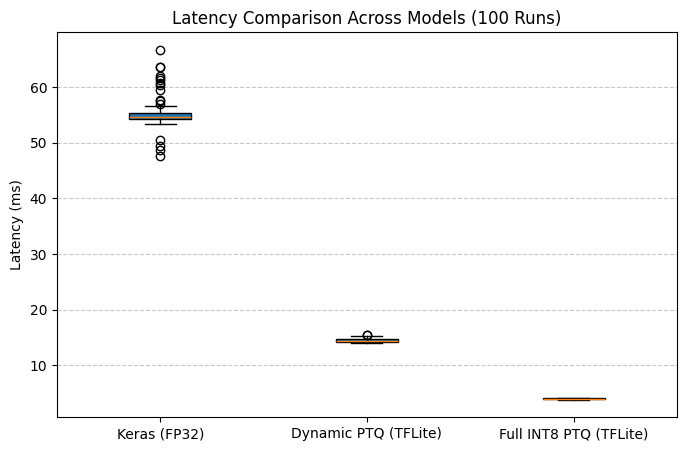

In [18]:
labels = ['Keras (FP32)', 'Dynamic PTQ (TFLite)', 'Full INT8 PTQ (TFLite)']
data = [keras_latencies, dynamic_ptq_latency, full_int8_ptq_latency]

# Plot
plt.figure(figsize=(8, 5))
plt.boxplot(data, labels=labels, patch_artist=True)
plt.ylabel("Latency (ms)")
plt.title("Latency Comparison Across Models (100 Runs)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

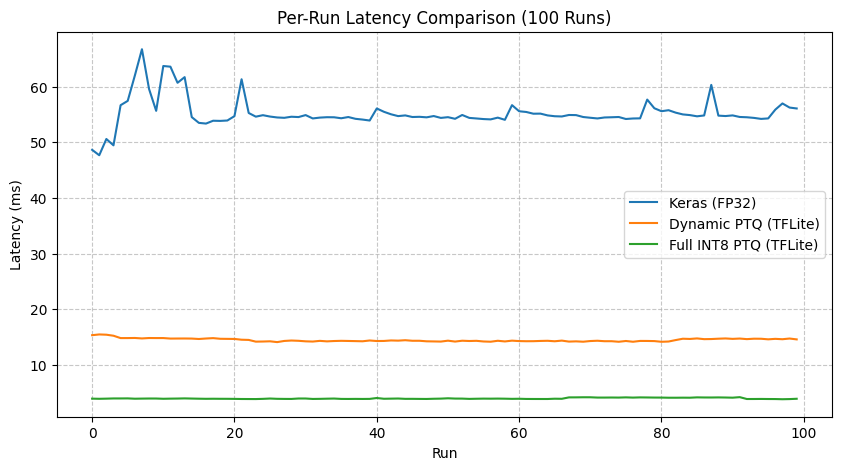

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(keras_latencies, label='Keras (FP32)')
plt.plot(dynamic_ptq_latency, label='Dynamic PTQ (TFLite)')
plt.plot(full_int8_ptq_latency, label='Full INT8 PTQ (TFLite)')
plt.xlabel("Run")
plt.ylabel("Latency (ms)")
plt.title("Per-Run Latency Comparison (100 Runs)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [20]:
print("Average Latencies:")
print(f"Keras (FP32): {np.mean(keras_latencies):.3f} ms")
print(f"Dynamic PTQ: {np.mean(dynamic_ptq_latency):.3f} ms")
print(f"Full INT8 PTQ: {np.mean(full_int8_ptq_latency):.3f} ms")

Average Latencies:
Keras (FP32): 55.240 ms
Dynamic PTQ: 14.462 ms
Full INT8 PTQ: 3.961 ms


In [23]:
print("Model Size:")
print(f"Keras (FP32): {get_file_size('steel_defect_clf_mobile_netv2_fine_tuning_scaling_patch_augmented_less_aggressive.keras'):.3f} MB")
print(f"Dynamic PTQ: {get_file_size('mobilenetv2_dynamic_ptq.tflite'):.3f} MB")
print(f"Full INT8 PTQ: {get_file_size('mobilenetv2_int8_ptq.tflite'):.3f} MB")

Model Size:
Keras (FP32): 23.333 MB
Dynamic PTQ: 2.399 MB
Full INT8 PTQ: 2.593 MB


In [24]:
predictions = model_mbnv2.predict(val_ds)
y_pred = np.argmax(predictions, axis=1)
y_true = np.concatenate([y for x, y in val_ds], axis=0)

from sklearn.metrics import classification_report, confusion_matrix
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

359/359 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step
Classification Report:
                 precision    recall  f1-score   support

        crazing       1.00      0.94      0.97        52
      inclusion       1.00      1.00      1.00        75
        patches       1.00      1.00      1.00        56
 pitted_surface       1.00      1.00      1.00        59
rolled-in_scale       0.95      1.00      0.98        61
      scratches       1.00      1.00      1.00        56

       accuracy                           0.99       359
      macro avg       0.99      0.99      0.99       359
   weighted avg       0.99      0.99      0.99       359



2025-11-09 13:18:15.485588: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## we need to patch our fine tuning since image net expects images in [-1, 1] range while ours are in [0, 255]

In [30]:
# Model 3: Fine tuning MobileNetV2

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical", input_shape=(img_height, img_width, 1)),
    layers.RandomRotation(0.075),        # modestly stronger rotation
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomZoom(0.075),
    layers.RandomContrast(0.10),
    layers.GaussianNoise(0.02),
], name="data_augmentation")

inputs = layers.Input(shape=(img_height, img_width, 1))

x = data_augmentation(inputs)

# 1. First, convert 1-channel grayscale to 3-channel "pseudo-RGB"
x = layers.Conv2D(3, (1, 1), padding='same')(x)

# 2. THEN, apply the rescaling expected by MobileNetV2
x = layers.Rescaling(1./127.5, offset=-1)(x)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False, # original clf is nto needed
    weights='imagenet'
)

# Freeze the base model
base_model.trainable = False
x = base_model(x, training=False)

# Add our custom clf head for thr 6 defects
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model_3 = tf.keras.Model(inputs, outputs)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model_3.compile(optimizer=optimizer,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

model_3.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 3)    │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,676 (8.64 MB)

 Trainable params: 7,692 (30.05 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [31]:
# PHASE 1
initial_epochs = 10
print("--- Starting Phase 1: Feature Extraction ---")
history_phase1 = model_3.fit(
  train_ds,
  validation_data=val_ds,
  epochs=initial_epochs
)

--- Starting Phase 1: Feature Extraction ---
Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.5611 - loss: 1.1549 - val_accuracy: 0.8468 - val_loss: 0.5946
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.8021 - loss: 0.5793 - val_accuracy: 0.9359 - val_loss: 0.3610
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.8785 - loss: 0.3917 - val_accuracy: 0.9387 - val_loss: 0.2441
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.9146 - loss: 0.2887 - val_accuracy: 0.9582 - val_loss: 0.1816
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.9326 - loss: 0.2269 - val_accuracy: 0.9721 - val_loss: 0.1398
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.9479 - loss: 0.1859 - val_accuracy: 0.9721 - val_loss: 0.1184
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.9542 - loss: 0.1537 - val_accuracy: 0.9833 - val_loss: 0.0965
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9625 - lo

In [32]:
# PHASE 2

base_model.trainable = True
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

# for layer in base_model.layers:
#     if isinstance(layer, tf.keras.layers.BatchNormalization):
#         layer.trainable = False

def freeze_batchnorms(layer):
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    if hasattr(layer, "layers"):
        for sub in layer.layers:
            freeze_batchnorms(sub)

freeze_batchnorms(base_model)

optimizer_fine_tune = tf.keras.optimizers.Adam(learning_rate=1e-5)
model_3.compile(
    optimizer=optimizer_fine_tune,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
print("\n--- Starting Phase 2: Fine-Tuning ---")

fine_tune_epochs = 10
total_epochs = initial_epochs + fine_tune_epochs

history_phase2 = model_3.fit(
    train_ds,
    epochs=total_epochs,
    initial_epoch=initial_epochs,
    validation_data=val_ds,
)

acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']

loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([min(plt.ylim()), 1])
# Add a vertical line to show where fine-tuning started
plt.axvline(initial_epochs - 1, color='gray', linestyle='--', label='Start Fine-Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
# Add a vertical line to show where fine-tuning started
plt.axvline(initial_epochs - 1, color='gray', linestyle='--', label='Start Fine-Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


--- Starting Phase 2: Fine-Tuning ---
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.9708 - loss: 0.0838 - val_accuracy: 0.9833 - val_loss: 0.0590
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.9750 - loss: 0.0537 - val_accuracy: 0.9805 - val_loss: 0.0422
Epoch 13/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9826 - loss: 0.0560 - val_accuracy: 0.9861 - val_loss: 0.0299
Epoch 14/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.9889 - loss: 0.0351 - val_accuracy: 0.9889 - val_loss: 0.0347
Epoch 15/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9882 - loss: 0.0373 - val_accuracy: 0.9944 - val_loss: 0.0221
Epoch 16/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.9889 - loss: 0.0259 - val_accuracy: 0.9944 - val_loss: 0.0129
Epoch 17/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9937 - loss: 0.0175 - val_accuracy: 1.0000 - val_loss: 0.0119
Epoch 18/20
20/45 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.9928 - 

KeyboardInterrupt: 

In [26]:
model_3.save('steel_defect_clf_mobile_netv2_fine_tuning_scaling_patch_augmented.keras')

In [9]:
predictions = model_mbnv2.predict(val_ds)
y_pred = np.argmax(predictions, axis=1)
y_true = np.concatenate([y for x, y in val_ds], axis=0)

359/359 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step


2025-11-09 09:14:19.016351: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [10]:
from sklearn.metrics import classification_report, confusion_matrix
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        52
      inclusion       1.00      0.97      0.99        75
        patches       1.00      1.00      1.00        56
 pitted_surface       1.00      1.00      1.00        59
rolled-in_scale       1.00      1.00      1.00        61
      scratches       0.97      1.00      0.98        56

       accuracy                           0.99       359
      macro avg       0.99      1.00      0.99       359
   weighted avg       0.99      0.99      0.99       359



In [11]:
confidences = np.max(predictions, axis=1)
for i in range(100):
    print(f"Sample {i}:")
    print(f"  Predicted class: {y_pred[i]}")
    print(f"  Confidence: {confidences[i]:.2%}")

Sample 0:
  Predicted class: 4
  Confidence: 100.00%
Sample 1:
  Predicted class: 1
  Confidence: 99.98%
Sample 2:
  Predicted class: 5
  Confidence: 100.00%
Sample 3:
  Predicted class: 0
  Confidence: 100.00%
Sample 4:
  Predicted class: 3
  Confidence: 100.00%
Sample 5:
  Predicted class: 1
  Confidence: 99.99%
Sample 6:
  Predicted class: 4
  Confidence: 100.00%
Sample 7:
  Predicted class: 1
  Confidence: 99.50%
Sample 8:
  Predicted class: 5
  Confidence: 100.00%
Sample 9:
  Predicted class: 4
  Confidence: 100.00%
Sample 10:
  Predicted class: 5
  Confidence: 99.97%
Sample 11:
  Predicted class: 5
  Confidence: 100.00%
Sample 12:
  Predicted class: 5
  Confidence: 100.00%
Sample 13:
  Predicted class: 1
  Confidence: 99.99%
Sample 14:
  Predicted class: 2
  Confidence: 100.00%
Sample 15:
  Predicted class: 3
  Confidence: 99.99%
Sample 16:
  Predicted class: 3
  Confidence: 99.98%
Sample 17:
  Predicted class: 0
  Confidence: 99.99%
Sample 18:
  Predicted class: 0
  Confidence: 

In [20]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
import numpy as np


Xs, Ys = [], []
for x_batch, y_batch in val_ds:          # iterate once
    Xs.append(x_batch.numpy())
    Ys.append(y_batch.numpy())

X = np.concatenate(Xs, axis=0)
y = np.concatenate(Ys, axis=0)

def cross_validate_trained_model(model, X, y, num_folds=5):
    """
    Evaluates a trained Keras model on K-fold splits of data.
    Does not retrain the model — just re-evaluates on different validation splits.
    """
    kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)
    scores = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_val, y_val = X[val_idx], y[val_idx]
        y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
        score = accuracy_score(y_val, y_pred)
        print(f"Fold {fold+1} accuracy: {score:.4f}")
        scores.append(score)

    print(f"\nMean accuracy: {np.mean(scores):.4f} ± {np.std(scores):.4f}")
    return scores

def cross_validate_full_int8(tflite_path, X, y, num_folds=5):
    interpreter = Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    # Get quantization parameters for input/output
    input_scale, input_zero_point = input_details['quantization']
    output_scale, output_zero_point = output_details['quantization']

    kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)
    scores = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        images_np, labels_np = X[val_idx], y[val_idx]
        
        # Loop through each image in the batch
        # The new model expects batch_size=1 since our generator used it

        all_predictions = []
        all_labels = []
        for i in range(images_np.shape[0]):
            image = images_np[i:i+1] # Get one image [1, 200, 200, 1]
            label = labels_np[i]
            
            # --- 1. Quantize the input image ---
            # (float32 / scale) + zero_point = int8
            image_quantized = (image / input_scale) + input_zero_point
            image_quantized = image_quantized.astype(input_details['dtype'])

            # Set the quantized image as input
            interpreter.set_tensor(input_details['index'], image_quantized)
            interpreter.invoke()
            
            # --- 2. Get the output and de-quantize it ---
            output_quantized = interpreter.get_tensor(output_details['index'])
            
            # (int8 - zero_point) * scale = float32
            output_float = (output_quantized.astype(np.float32) - output_zero_point) * output_scale

            # Get the final prediction
            predicted_label = np.argmax(output_float[0])
            
            all_predictions.append(predicted_label)
            all_labels.append(label)

        all_predictions = np.array(all_predictions)
        all_labels = np.array(all_labels)
    
        # Compute metrics
        score  = np.mean(all_predictions == all_labels)
        print(f"Fold {fold+1} accuracy: {score:.4f}")
        scores.append(score)


    print(f"\nMean accuracy: {np.mean(scores):.4f} ± {np.std(scores):.4f}")
    return scores
    
cross_validate_trained_model(model_mbnv2, X, y, num_folds=5)
cross_validate_full_int8("mobilenetv2_int8_ptq.tflite", X_val, y_val, num_folds=5)

2025-11-09 16:58:17.177227: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Fold 1 accuracy: 1.0000
Fold 2 accuracy: 0.9722
Fold 3 accuracy: 0.9861
Fold 4 accuracy: 1.0000
Fold 5 accuracy: 1.0000

Mean accuracy: 0.9917 ± 0.0111
Fold 1 accuracy: 1.0000
Fold 2 accuracy: 0.9583
Fold 3 accuracy: 0.9861
Fold 4 accuracy: 1.0000
Fold 5 accuracy: 0.9718

Mean accuracy: 0.9833 ± 0.0163


[1.0, 0.9583333333333334, 0.9861111111111112, 1.0, 0.971830985915493]

# 3. quantization aware training

In [7]:
import tensorflow_model_optimization as tfmot

In [15]:
prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

num_images = len(train_ds)
end_step = np.ceil(num_images / batch_size).astype(np.int32) * 2

# 50% pruning
pruning_params = {
    'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(initial_sparsity=0.50, final_sparsity=0.80, begin_step=0, end_step=end_step)
}